### `Event` Class – Representing Temporal Events

The `Event` class is a fundamental building block in the *Open-the-Chests* environment. It models a single **temporal event** with associated metadata. Each event has:

* A **type**: a string label (e.g., `'A'`, `'B'`) describing the nature of the event.
* A dictionary of **attributes**: contextual information (e.g., color, label, source).
* A **start time** and an **end time**, defining when the event occurs.
* A **duration**, computed automatically.

This structure supports operations essential for **temporal reasoning**, like comparing event end times, shifting events in time, and converting to a dictionary for serialization or rule evaluation.

---

### Class Summary

```python
event = Event(
    e_type="A",
    e_attributes={"color": "blue", "background": "red"},
    t_start=2.5,
    t_end=5.0
)
```

| Method                    | Purpose                                               |
| ------------------------- | ----------------------------------------------------- |
| `get_type()`              | Returns the event type string                         |
| `get_attribute_val(attr)` | Looks up a specific attribute by name                 |
| `set_time(start, end)`    | Safely updates the time interval                      |
| `shifted(delta)`          | Returns a **new** event shifted by `delta` time units |
| `to_dict()`               | Converts to a dictionary for storage or processing    |

---

### Comparison Operators

The class overrides several comparison operators based on the **event end time**, which is useful for sorting or logic evaluations:

* `event1 < event2`: True if `event1` ends before `event2`
* `event1 >= event2`: True if `event1` ends after or at the same time as `event2`
* `event1 == event2`: True if type, attributes, and times all match (with float tolerance)

---

### Example

```python
e1 = Event("X", {"id": 1}, 3.0, 6.0)
e2 = e1.shifted(2.0)

print(e2)  # Event(type='X', attr={'id': 1}, start=5.0, end=8.0)
print(e1 < e2)  # True
print(e1.to_dict())  
```

In [1]:
from openthechests.src.elements.Event import Event

# Create an event with type 'A', two attributes, and a start/end time
event1 = Event(
    e_type="A",
    e_attributes={"color": "red", "source": "sensor1"},
    t_start=2.0,
    t_end=5.0
)

# Print a user-friendly string representation
print("Original event:")
print(event1)

# Access event components
print("\nType of event:", event1.get_type())
print("Event color attribute:", event1.get_attribute_val("color"))
print("Event duration:", event1.get_duration())

# Shift the event forward in time by 3.0 units
event2 = event1.shifted(3.0)
print("\nShifted event (3.0 units later):")
print(event2)

# Compare the two events based on end time
print("\nComparison (event1 ends before event2):", event1 < event2)

# Convert to dictionary (useful for serialization or rule evaluation)
event_dict = event1.to_dict()
print("\nEvent as dictionary:")
print(event_dict)

# Attempt to create an invalid event (end < start) - this will raise an assertion error
try:
    invalid_event = Event("B", {}, t_start=5.0, t_end=2.0)
except AssertionError as e:
    print("\nError creating invalid event:", e)


Original event:
Event(type='A', attr={'color': 'red', 'source': 'sensor1'}, start=2.0, end=5.0)

Type of event: A
Event color attribute: red
Event duration: 3.0

Shifted event (3.0 units later):
Event(type='A', attr={'color': 'red', 'source': 'sensor1'}, start=5.0, end=8.0)

Comparison (event1 ends before event2): True

Event as dictionary:
{'e_type': 'A', 'color': 'red', 'source': 'sensor1', 'start': 2.0, 'end': 5.0, 'duration': 3.0}

Error creating invalid event: Event start must be ≤ end.


### `InteractiveBox` Class – Reactive, Openable State Machine

The `InteractiveBox` is a key object representing a **reactive, openable box** that transitions between different internal states. It is used in environments like *Open-the-Chests* to simulate situations where an agent must identify the right time to interact with a target (e.g., press a button to open a box) based on **temporal logic rules**.

---

### Core Concepts

Each box has **three binary state indicators** stored in `self.state`:

| State Key | Meaning                                                      |
| --------- | ------------------------------------------------------------ |
| `_open`   | True if the box has been successfully opened.                |
| `_ready`  | True if the box is ready to be opened via button press.      |
| `active`  | True if the box is currently active (i.e., tracking events). |

These states evolve based on the environment’s event stream and agent interactions.

---

### State Transitions

Typical box lifecycle:

1. **Activate** the box (`_activate`) — begins monitoring for pattern satisfaction.
2. **Ready** state (`_ready`) is triggered when the correct event pattern occurs.
3. **Agent presses button** (`press_button`) — if ready and active, the box is opened.
4. If not opened in time, the box is **deactivated** (`_deactivate`), possibly to be reactivated later.

> You don’t call `_activate`, `_deactivate`, or `_ready` directly — these are used internally by `update()` based on event-driven signals.

---

### Methods Summary

| Method                                     | Description                                                     |
| ------------------------------------------ | --------------------------------------------------------------- |
| `press_button()`                           | Try to open the box. Returns `True` if successful.              |
| `update(signal)`                           | Update box state with signals like `'active'` or `'satisfied'`. |
| `reset()`                                  | Reset box to initial state.                                     |
| `get_state()`                              | Return dictionary with current status flags.                    |
| `is_ready()` / `is_open()` / `is_active()` | Check state flags directly.                                     |

---

### Example Usage

```python
box = InteractiveBox(id=1, verbose=True)

# Activate the box via signal
box.update(signal=["active"])

# Simulate pattern satisfaction
box.update(signal=["satisfied"])

# Agent attempts to open
success = box.press_button()
print("Was the box opened?", success)
```

---

### Design Insight

The `InteractiveBox` is a simplified **finite-state machine** controlled by:

* External input (`update` signals)
* Timing constraints (checked inside `update`)
* User interaction (`press_button`)

This makes it a reusable abstraction for modeling **time-sensitive decisions** in learning environments, particularly those grounded in temporal logic.

In [2]:
from openthechests.src.elements.InteractiveBox import InteractiveBox

# Create a box instance with verbose output to trace transitions
box = InteractiveBox(id=1, verbose=True)

# Helper function to print state using public methods
def print_state(label):
    print(f"{label}")
    print(f"  Ready  : {box.is_ready()}")
    print(f"  Active : {box.is_active()}")
    print(f"  Open   : {box.is_open()}")

# Step 0: Initial state
print("Initial state:")
print_state("Initial")

# Step 1: Activate the box
print("\nSending signal: ['active']")
box.update(signal=["active"])
print_state("After activation")

# Step 2: Mark pattern as satisfied
print("\nSending signal: ['satisfied']")
box.update(signal=["satisfied"])
print_state("After pattern satisfaction")

# Step 3: Press the button to open the box
print("\nPressing button...")
was_opened = box.press_button()
print("Box opened?", was_opened)
print_state("After button press")

# Step 4: Update again after opening (should do nothing)
print("\nSending another update (box already open):")
box.update(signal=["satisfied", "active"])
print_state("After post-open update")

# Step 5: Reset the box
print("\nResetting box...")
box.reset()
print_state("After reset")

# Step 6: Send both signals again after reset
print("\nSending signal: ['active', 'satisfied'] after reset")
box.update(signal=["active", "satisfied"])
print_state("After reactivation and satisfaction")


Initial state:
Initial
  Ready  : False
  Active : False
  Open   : False

Sending signal: ['active']
Activating box 1.
After activation
  Ready  : False
  Active : True
  Open   : False

Sending signal: ['satisfied']
Ready box 1.
After pattern satisfaction
  Ready  : True
  Active : True
  Open   : False

Pressing button...
Opening box 1.
Box opened? True
After button press
  Ready  : False
  Active : False
  Open   : True

Sending another update (box already open):
After post-open update
  Ready  : False
  Active : False
  Open   : True

Resetting box...
After reset
  Ready  : False
  Active : False
  Open   : False

Sending signal: ['active', 'satisfied'] after reset
Activating box 1.
Ready box 1.
After reactivation and satisfaction
  Ready  : True
  Active : True
  Open   : False


### `Pattern` Class – Procedural Event Generation with Temporal Logic

The `Pattern` class represents a **procedural definition of a temporal event sequence** that a box expects. It parses and stores a list of commands — like instantiating events and defining **temporal constraints** — that form a mini-program to generate a pattern.

These patterns are later interpreted and sampled during environment execution, producing a stream of synthetic events that must match the expected logic. The `Pattern` class defines how a box should **react to incoming events** based on a list of instructions. Each pattern controls:

* When a box becomes **ready** (based on event sequences)
* When a box **times out** (via `timeout`)
* How **noisy or uncertain** its behavior should be (via `noise`)

This class separates the **high-level event logic** (defined in instructions) from the mechanics of the box itself (`InteractiveBox`), making the system modular and interpretable.

---

### Components of a Pattern

* **`id`**: A unique numeric identifier.
* **`instruction`**: A list of structured commands that define which events to expect and how to match them. This excludes control directives like `"delay"` or `"noise"`.
* **`timeout`**: The maximum amount of time the box stays inactive after before activating.
* **`noise`**: A numeric value indicating how much uncertainty should be introduced during pattern generation.
* **`full_pattern`**: A visual/logging aid for GUIs or debugging — tracks resolved pattern elements.

| Method             | Description                                                                              |
| ------------------ | ---------------------------------------------------------------------------------------- |
| `sample_timeout()` | Returns a random float between `0` and `timeout` — used for adding temporal variability. |
| `get_timeout()`    | Returns the pattern’s fixed timeout.                                                     |
| `get_noise()`      | Returns the pattern’s fixed noise level.                                                 |
| `reset()`          | Clears `full_pattern`, e.g., on environment reset.                                       |

---

### Instruction Format

Each pattern consists of a list of `command` dictionaries. Commands fall into **three categories**:

#### 1. Delay / Noise (optional setup)

* `"delay"`: Gap between occurences of a pattern (used as a timeout)
* `"noise"`: Amount of additional events injected during pattern execution

```python
{"command": "delay", "parameters": 10}
{"command": "noise", "parameters": 0.1}
```

---

#### 2. Event Instantiation

* `"instantiate"` creates an event template with:

  * **Type** (e.g., `'A'`)
  * **Attributes** (dict of symbolic features)
  * **Timing distribution** (e.g., `{"mu": 5, "sigma": 2}`)
  * Named using `variable_name` for later reference

```python
{
  "command": "instantiate",
  "parameters": ("A", {"bg": "red", "fg": "red"}, {"mu": 2, "sigma": 2}),
  "variable_name": "e1"
}
```

---

#### 3. Temporal Allen Relations

* Commands like `"after"`, `"before"`, `"overlaps"`, etc., define how two instantiated events relate in time
* `parameters` gives a pair of variable names
* `other` can include probabilistic gap distributions

```python
{
  "command": "after",
  "parameters": ["e1", "e2"],
  "variable_name": "e1",
  "other": {"gap_dist": {"mu": 4, "sigma": 1}}
}
```

This means **"e2 comes after e1"**, with the gap duration sampled from a normal distribution.

---

### Example Pattern Definition

```python
[
    {"command": "delay", "parameters": 10},
    {"command": "noise", "parameters": 0},
    {"command": "instantiate", "parameters": ("A", {"bg": "red"}, {"mu": 2, "sigma": 1}), "variable_name": "e1"},
    {"command": "instantiate", "parameters": ("B", {"bg": "blue"}, {"mu": 5, "sigma": 1}), "variable_name": "e2"},
    {"command": "after", "parameters": ["e1", "e2"], "variable_name": "e1"}
]
```

> This pattern defines two events and specifies that `e2` must happen **after** `e1`.

---

### Summary

| Command                   | Purpose                                                   |
| ------------------------- | --------------------------------------------------------- |
| `delay`                   | Sets max delay between pattern occurnece                  |
| `noise`                   | Controls stochasticity of generation                      |
| `instantiate`             | Defines an event (type + attributes + timing)             |
| `after`, `overlaps`, etc. | Adds a temporal logic constraint between two named events |

This command list forms a **mini temporal logic program**, enabling complex sequences to be defined compactly and stochastically.

Timeout (max wait before pattern): 10
Noise level: 0
Random sampled timeout: 7.458192188489026

Filtered event instructions:
  - instantiate -> ('A', {'bg': 'yellow', 'fg': 'red'}, {'mu': 2, 'sigma': 2}) -> e1
  - instantiate -> ('A', {'bg': 'blue', 'fg': 'red'}, {'mu': 6, 'sigma': 1}) -> e2
  - after -> ['e2', 'e1'] -> e2
No error during validation, meaning the pattern is syntactically correct.

Visual representations of pattern:


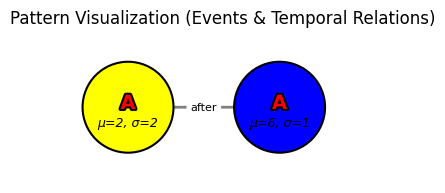

In [3]:
from openthechests.src.elements.Pattern import Pattern
from openthechests.src.elements.Pattern import validate_pattern_instructions

# Define a mock instruction set:
# - Includes a timeout (`delay`)
# - No noise
# - Two events: e1 and e2
# - e2 is defined to happen AFTER e1
instructions = [
    # Pattern timeout: max duration allowed for matching
    {"command": "delay", "parameters": 10},
    
    # Pattern noise: how much uncertainty to add (e.g. to event timing or attributes)
    {"command": "noise", "parameters": 0},

    # Instantiate event e1 of type "A", with red colors, and duration sampled from N(mu=2, sigma=2)
    {
        "command": "instantiate",
        "parameters": ("A", {"bg": "yellow", "fg": "red"}, {"mu": 2, "sigma": 2}),
        "variable_name": "e1"
    },

    # Instantiate event e2 of type "A" with same attributes, but different timing
    {
        "command": "instantiate",
        "parameters": ("A", {"bg": "blue", "fg": "red"}, {"mu": 6, "sigma": 1}),
        "variable_name": "e2"
    },

    # Define a temporal relation: e2 must occur AFTER e1, with a gap ~ N(mu=4, sigma=1)
    {
        "command": "after",
        "parameters": ["e2", "e1"],
        "variable_name": "e2",
        "other": {"gap_dist": {"mu": 4, "sigma": 1}}
    }
]

# Create the Pattern instance
pattern = Pattern(instruction=instructions, id=0)

# Show timeout and noise parameters
print("Timeout (max wait before pattern):", pattern.get_timeout())
print("Noise level:", pattern.get_noise())

# Sample a random timeout duration within [0, timeout]
print("Random sampled timeout:", pattern.sample_timeout())

# List the parsed instruction (excluding delay/noise)
print("\nFiltered event instructions:")
for cmd in pattern.instruction:
    print(f"  - {cmd['command']} -> {cmd.get('parameters', '?')} -> {cmd.get('variable_name', '?')}")


# Validate the pattern as correct
print("No error during validation, meaning the pattern is syntactically correct.")
validate_pattern_instructions(instructions)

# Visualise the pattern as sequence of annotated nodes
print("\nVisual representations of pattern:")
pattern.visualize()

### `Parser` Class – Turning Instructions into Events

The `Parser` is the **event generator** in the *Open-the-Chests* framework.
It bridges the gap between **pattern instructions** and actual `Event` objects in the simulation.

It knows:

* **What types of events** can exist
* **What attributes** they can have
* **How to add noise events**
* **How to link events** in time using Allen relations

---

### Responsibilities

1. **Convert events to/from labelled form**

   * `event_to_labelled(event)`: encodes type/attributes as integers
   * `labelled_to_event(event)`: decodes integers back to human-readable form

2. **Generate noise events**

   * `make_noise(before)`: creates an event of a noise type before a given time

3. **Instantiate full patterns**

   * `instantiate_pattern(instructions)`: takes a list of instructions (instantiate + Allen relations) and produces a sorted list of `Event` objects

4. **Track and sample durations**

   * Keeps min/max durations seen
   * Samples durations when not explicitly provided

---

### Example Workflow

```python
parser = Parser(
    all_event_types=["A", "B"],
    all_noise_types=["N1", "N2"],
    all_event_attributes={"color": ["red", "blue"], "shape": ["square", "circle"]},
    all_noise_attributes={"color": ["gray"], "shape": ["noise"]}
)

# Example instructions
instructions = [
    {"command": "instantiate",
     "parameters": ("A", {"color": "red", "shape": "circle"}, {"mu": 2, "sigma": 1}),
     "variable_name": "e0"},
    {"command": "instantiate",
     "parameters": ("B", {"color": "blue", "shape": "square"}, {"mu": 3, "sigma": 1}),
     "variable_name": "e1"},
    {"command": "after",
     "parameters": ["e0", "e1"],
     "variable_name": "e0",
     "other": {"gap_dist": {"mu": 4, "sigma": 1}}}
]

# Generate events from instructions
events = parser.instantiate_pattern(instructions)

for e in events:
    print(e)
```

---

### Allen Relations in the Parser

Allen relations are **temporal positioning rules** between events (from `utils/allen.py`):

| Relation     | Effect                                            |
| ------------ | ------------------------------------------------- |
| `after`      | One event occurs after another, with optional gap |
| `during`     | One event is contained entirely within another    |
| `met_by`     | One event starts immediately after another ends   |
| `overlapped` | Events partially overlap                          |
| `starts`     | One event starts with another                     |
| `ends`       | One event ends with another                       |
| `equals`     | Events start and end at the same time             |

---

### Key Takeaways

* **Parser is the execution engine** for pattern instructions.
* Converts symbolic pattern definitions into **real event timelines**.
* Handles noise, duration sampling, and event attribute assignment automatically.
* Supports both **manual specifications** and **randomized generation**.


In [4]:
from openthechests.src.elements.Event import Event
from openthechests.src.elements.Parser import Parser

# ----------------------------------------------------------
# 1. Create a Parser instance with a small set of types/attributes
# ----------------------------------------------------------
parser = Parser(
    all_event_types=["A", "B"],                  # Allowed real event types
    all_noise_types=["N1", "N2"],                # Allowed noise event types
    all_event_attributes={                       # Attributes for real events
        "fg": ["red", "blue"],
        "bg": ["yellow", "green"]
    },
    all_noise_attributes={                       # Attributes for noise events
        "fg": ["black"],
        "bg": ["gray"]
    }
)

print("Parser initialized.")
print("All event types:", parser.all_event_types)
print("All noise types:", parser.all_noise_types)
print("All combined types:", parser.all_types)
print()

# ----------------------------------------------------------
# 2. Create a manual Event and convert it to a labelled form
# ----------------------------------------------------------
event = Event(
    e_type="A",
    e_attributes={"fg": "red", "bg": "yellow"},
    t_start=0.0,
    t_end=2.5
)

print("Original Event:", event)

labelled_event = parser.event_to_labelled(event)
print("Labelled Event (type/attributes as integers):", labelled_event)

# Convert back to readable event
decoded_event = parser.labelled_to_event(labelled_event)
print("Decoded Event:", decoded_event)
print()

# ----------------------------------------------------------
# 3. Generate a noise event that ends before a given time
# ----------------------------------------------------------
noise_event = parser.make_noise(before=5.0)
print("Random Noise Event:", noise_event)
print()

# ----------------------------------------------------------
# 4. Test the internal _make_event method for random event creation
# ----------------------------------------------------------
random_event = parser._make_event()  # No params -> random type, random attrs, sampled duration
print("Randomly Generated Event:", random_event)

# Generate with fixed type/attrs/duration distribution
fixed_event = parser._make_event(
    e_type="B",
    attributes={"fg": "blue", "bg": "green"},
    duration_distribution={"mu": 4, "sigma": 1}
)
print("Fixed Parameters Event:", fixed_event)
print()

# ----------------------------------------------------------
# 5. Show how the parser keeps track of duration statistics
# ----------------------------------------------------------
print("Duration stats so far:", parser.min_max_durations)
print("Random duration distribution based on stats:", parser._get_random_duration_dist())


Parser initialized.
All event types: ['A', 'B']
All noise types: ['N1', 'N2']
All combined types: ['A', 'B', 'N1', 'N2']

Original Event: Event(type='A', attr={'fg': 'red', 'bg': 'yellow'}, start=0.0, end=2.5)
Labelled Event (type/attributes as integers): Event(type='0', attr={'fg': 0, 'bg': 0}, start=0.0, end=2.5)
Decoded Event: Event(type='A', attr={'fg': 'red', 'bg': 'yellow'}, start=0.0, end=2.5)

Random Noise Event: Event(type='N2', attr={'fg': 'black', 'bg': 'gray'}, start=0.399, end=3.508)

Randomly Generated Event: Event(type='A', attr={'fg': 'red', 'bg': 'green'}, start=0, end=1.0)
Fixed Parameters Event: Event(type='B', attr={'fg': 'blue', 'bg': 'green'}, start=0, end=3)

Duration stats so far: {'min': 1, 'max': 4}
Random duration distribution based on stats: {'mu': 2.5, 'sigma': 1.5}



Generated events:
Event(type='A', attr={'bg': 'yellow', 'fg': 'red'}, start=0, end=4)
Event(type='A', attr={'bg': 'blue', 'fg': 'red'}, start=9, end=15.482)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


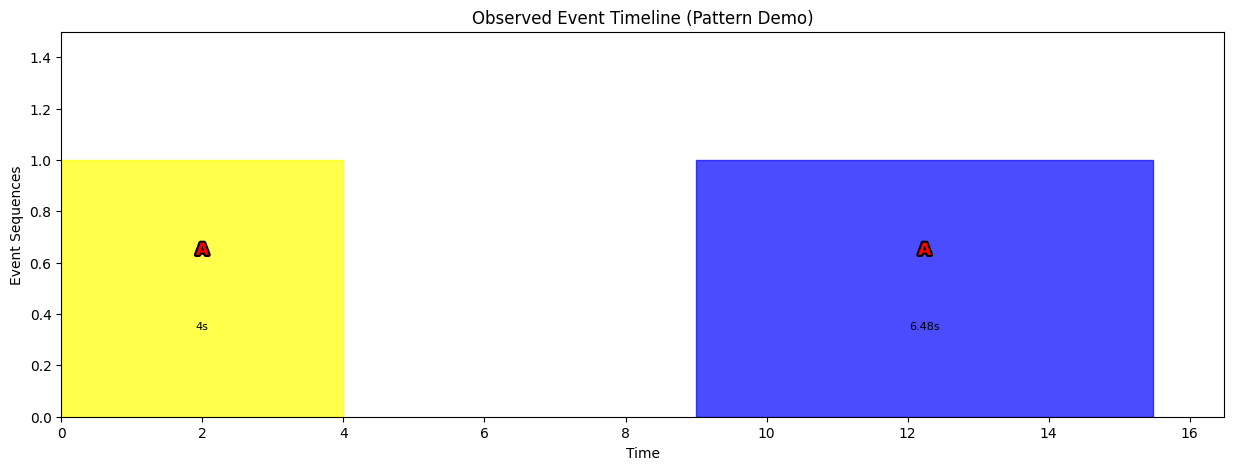

In [5]:
from openthechests.src.utils.modified_plotting import draw_event_sequence_matplot

# Create a parser with allowed types/attributes for both events and noise
parser = Parser(
    all_event_types=["A"],
    all_noise_types=["N"],
    all_event_attributes={"bg": ["yellow", "blue"], "fg": ["red", "black"]},
    all_noise_attributes={"bg": ["gray"], "fg": ["white"]}
)

# Use parser to instantiate events from the pattern instructions
events = parser.instantiate_pattern(pattern.instruction)

# Print the events to see details
print("\nGenerated events:")
for e in events:
    print(e)

# Draw the event sequence as a timeline
draw_event_sequence_matplot(events, env_name="Pattern Demo")


### `Generator` – Driving Event Timelines from Patterns

The `Generator` is the **orchestrator** that turns one or more `Pattern` objects into actual **timelines of events**, ready to be used in an environment loop.

It uses a `Parser` to:

* Instantiate events according to a pattern's **instructions**.
* Add **noise events** where specified.
* Keep track of **event stacks** for each pattern (future events yet to happen).

---

### Responsibilities

1. **Manage timelines per pattern**

   * Each pattern has its own **event stack** (sorted list of upcoming events).
   * Stacks are reset with `reset()` and filled with new events.

2. **Generate noise events**

   * Noise count is based on a **binomial distribution**:
         $$
        \text{count} \sim \text{Binomial}(n=\text{\#events},\ p=\text{noise ratio})
        $$
        Where:

        - $n$ = number of real events in the pattern
        - $p$ = noise ratio from the pattern’s `noise` parameter
   * Noise events are placed before the pattern's last event ends.

3. **Fill an event stack for a pattern**

   * `_fill_event_stack(pattern, last_generated_event=None)` builds the full list of events for a pattern in a single call:

     1. Draws a random **start offset** using `pattern.sample_timeout()`.
     2. Uses the parser’s `instantiate_pattern()` to create the pattern’s core events.
     3. **Shifts** all events by the start offset so they happen later in the timeline.
     4. Generates noise events for the pattern, also shifted.
     5. Merges the shifted real events and noise events, then sorts them by time.
     6. Stores the result in the pattern’s `full_pattern` for later visualization.

4. **Handle event progression**

   * `next_event()` pops the earliest event from all stacks.
   * If a stack becomes empty, it’s refilled for that pattern.
   * Produces **signals** like `"active"` and `"satisfied"` for state tracking.

5. **Support timeline control**

   * `disable_timeline(pattern_id)`: removes a pattern’s stack.
   * `get_timeline()`: previews the *next* event in each pattern's stack.

---

### Workflow Example

```python
# Assume parser is a Parser instance and patterns is a list of Pattern objects
gen = Generator(parser, patterns, verbose=True)

# Fill all event stacks
gen.reset()

# Process events in chronological order
for _ in range(10):
    event, signal = gen.next_event()
    print("Next event:", event)
    print("Signal:", signal)
```

---

###  Key Methods

| Method                                                  | Purpose                                                                 |
| ------------------------------------------------------- | ----------------------------------------------------------------------- |
| `reset()`                                               | Clears and regenerates event stacks from patterns.                      |
| `_fill_event_stack(pattern, last_generated_event=None)` | Generates all events + noise for a pattern, with a random start offset. |
| `_generate_noise_events(noise, end, len)`               | Samples noise events proportionally to pattern length.                  |
| `next_event()`                                          | Returns earliest event across stacks + update signals.                  |
| `disable_timeline(id)`                                  | Removes a pattern’s event stack.                                        |
| `get_timeline()`                                        | Returns the next event for each active pattern.                         |

---

### Signals Explained

* `"active"` → This pattern currently has an event overlapping with the most recent processed event.
* `"satisfied"` → The current stack for this pattern has been completed.



Processed events:
Event(type='A', attr={'bg': 'yellow', 'fg': 'black'}, start=4.232, end=6.019) -> Signals: {0: ['active'], 1: ['active']}
Event(type='A', attr={'bg': 'yellow', 'fg': 'black'}, start=3.697, end=6.197) -> Signals: {1: ['active'], 0: ['active']}
Event(type='N', attr={'bg': 'gray', 'fg': 'white'}, start=5.084, end=10.91) -> Signals: {0: ['active'], 1: ['active']}
Event(type='A', attr={'bg': 'blue', 'fg': 'white'}, start=9.019, end=11.519) -> Signals: {0: ['active', 'satisfied'], 1: ['active']}
Event(type='A', attr={'bg': 'blue', 'fg': 'white'}, start=10.278, end=13.302) -> Signals: {1: ['active', 'satisfied']}
Event(type='A', attr={'bg': 'yellow', 'fg': 'black'}, start=14.822, end=17.102) -> Signals: {0: ['active'], 1: ['active']}
Event(type='A', attr={'bg': 'yellow', 'fg': 'black'}, start=16.033, end=17.533) -> Signals: {1: ['active']}
Event(type='N', attr={'bg': 'gray', 'fg': 'white'}, start=19.847, end=23.52) -> Signals: {0: ['active'], 1: ['active']}
Event(type='A', a

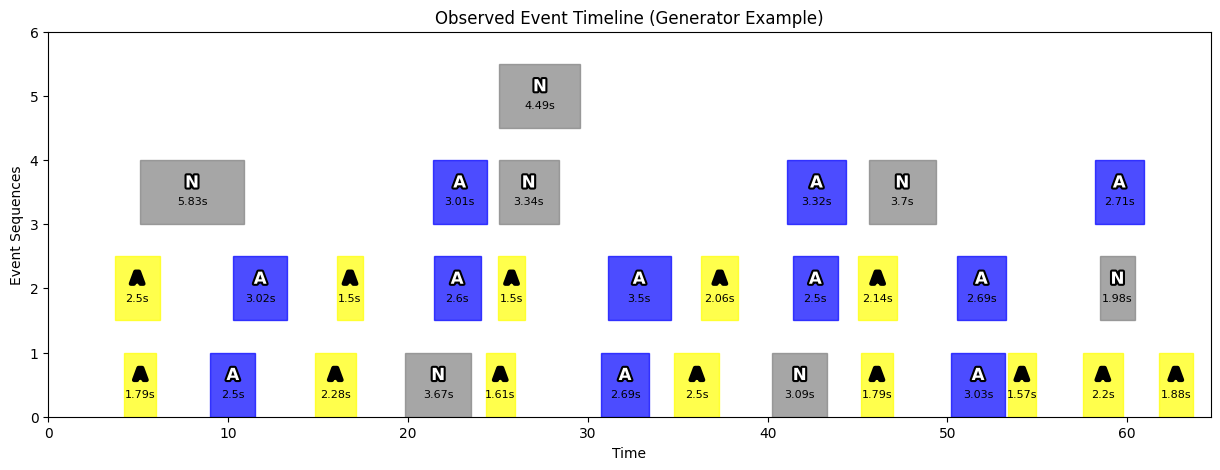

In [6]:
from openthechests.src.elements.Parser import Parser
from openthechests.src.elements.Pattern import Pattern, validate_pattern_instructions
from openthechests.src.elements.Generator import Generator
from openthechests.src.utils.modified_plotting import draw_event_sequence_matplot

# -------------------------------
# 1. Define a simple pattern
# -------------------------------
instructions = [
    {"command": "delay", "parameters": 5},
    {"command": "noise", "parameters": 0.2},

    # First event
    {
        "command": "instantiate",
        "parameters": ("A", {"bg": "yellow", "fg": "black"}, {"mu": 2, "sigma": 0.5}),
        "variable_name": "e1"
    },

    # Second event
    {
        "command": "instantiate",
        "parameters": ("A", {"bg": "blue", "fg": "white"}, {"mu": 3, "sigma": 0.5}),
        "variable_name": "e2"
    },

    # Allen relation: e2 AFTER e1
    {
        "command": "after",
        "parameters": ["e2", "e1"],
        "variable_name": "e2",
        "other": {"gap_dist": {"mu": 4, "sigma": 1}}
    }
]


# Create pattern object
pattern = Pattern(instruction=instructions, id=0)
pattern2 = Pattern(instruction=instructions, id=1)

# -------------------------------
# 2. Create a parser
# -------------------------------
parser = Parser(
    all_event_types=["A"],
    all_noise_types=["N"],
    all_event_attributes={"bg": ["yellow", "blue"], "fg": ["black", "white"]},
    all_noise_attributes={"bg": ["gray"], "fg": ["white"]}
)

# -------------------------------
# 3. Initialize the generator
# -------------------------------
gen = Generator(parser, [pattern, pattern2], verbose=False)

# Fill initial event stacks
gen.reset()

# -------------------------------
# 4. Process events
# -------------------------------
all_events = []
all_signals = []

while True:
    event, signal = gen.next_event()
    if event.type == "Empty":  # No more events
        break
    all_events.append(event)
    all_signals.append(signal)

    # Stop after a fixed number of steps for this example
    if len(all_events) > 30:
        break

# -------------------------------
# 5. Show results
# -------------------------------
print("\nProcessed events:")
for ev, sig in zip(all_events, all_signals):
    print(ev, "-> Signals:", sig)

# -------------------------------
# 6. Visualize event timeline
# -------------------------------
draw_event_sequence_matplot(all_events, env_name="Generator Example")
